# Bank Data Analysis

# Objective

In this case study, you will be working on Banking Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to give you hands-on experience in analyzing large-scale banking datasets using PySpark and AWS services. You will apply techniques learned in data analytics to clean, transform, and explore banking data, drawing meaningful insights to support financial decision-making. Apart from understanding how big data tools can optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing market capitalization trends, currency conversions, and global banking performance. Additionally, you will use AWS S3 to store the processed data once the ETL pipeline is complete, ensuring efficient data management and retrieval.


# Business Value

The banking industry operates in a highly competitive and globalized market where financial institutions must continuously monitor their market position, performance, and currency fluctuations. To stay competitive, banks must leverage data-driven insights to optimize their financial strategies, assess market trends, and make informed decisions. In this assignment, you will analyze banking data to uncover patterns in market capitalization, currency conversions, and global rankings. With Apache Spark's ability to handle large datasets efficiently, financial institutions can process vast amounts of data in real-time, helping them make faster and more informed decisions.


As an analyst at a financial institution, your task is to examine historical banking data to derive actionable insights that can drive strategic growth. Your analysis will help identify the top 10 largest banks by market capitalization, convert market cap values into multiple currencies (USD, GBP, EUR, INR), and store the processed data for easy retrieval. To enhance scalability and accessibility, you will utilize AWS S3 for data storage, ensuring seamless integration with cloud-based analytics tools. By leveraging big data analytics and cloud services, financial institutions can streamline operations, enhance decision-making, and maximize revenue opportunities.


# Dataset

The data for this project can be accessed from the following [wikipedia link](https://web.archive.org/web/20230908091635/https://en.wikipedia.org/wiki/List_of_largest_banks).

The dataset used in this analysis comprises global banking data extracted from a Wikipedia page (List of Largest Banks) archived as of September 2023.

It includes rankings of the world's largest banks based on market capitalization (in USD billions) and is structured into a single table with three columns. The data was scraped programmatically, cleaned, and transformed using PySpark to support cross-currency analysis. Exchange rate data (for USD, GBP, EUR, and INR) was sourced from a CSV file to enable currency conversions. The processed dataset is stored in CSV and SQLite formats for accessibility and efficient querying.

The dataset consists of a single table (Largest_banks) with the following three key attributes:
- **Rank:** Numerical position of the bank based on market capitalization.
- **Bank Name:** Name of the financial institution.
- **Market Cap (USD Billion):** Market valuation of the bank in USD billions.
This dataset enables analysis of global banking trends, cross-currency valuations, and the relative market dominance of financial institutions.

An additional data on market exchange rates is available to compare the marketcap dealing with different currencies.


<h2>Assignment Tasks</h2>

<ol>
    <li>
        <strong>Data Preparation</strong>
        <p>The dataset consists of a structured table containing global banking data. Before performing any analysis, it is crucial to prepare the data to ensure consistency and efficiency in processing.</p>
        Check for data consistency and ensure all columns are correctly formatted.<br>
        Structure and prepare the data for further processing and analysis.<br>
</br>
    <li>
        <strong>Data Cleaning</strong>
        <ul>
            2.1. <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.<br>
            2.2. <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.<br>
            2.3. <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.<br>
        </ul>
</br>
    <li>
        <strong>Exploratory Data Analysis:</strong></br>
            EDA Finding Patterns - Analyze the dataset and find patterns based on the following points:
                <ul>
                    3.1. Convert PySpark DataFrame to Pandas DataFrame for visualization.<br>
                    3.2. Analyze the distribution of market capitalization using a histogram.<br>
                    3.3. Identify the top 10 banks by market capitalization using a bar chart.<br>
                    3.4. Visualize the relationship between market capitalization and bank ranking using a scatter plot.<br>
                    3.5. Use a boxplot to examine the spread and outliers in market capitalization.<br>
                    3.6. Display the quartile distribution of market capitalization using a violin plot.<br>
                    3.7. Compute cumulative market share and visualize it with a line plot.<br>
                    3.8. Categorize banks into market capitalization ranges and analyze their distribution using a bar chart.<br>
                    3.9. Calculate and display market share distribution of top 10 banks using a pie chart.<br>
                </ul>
        </ul>
</br>
    <li>
        <strong>Banking Data ETL Querying</strong>
        <ul>
            4.1. Perform Advanced Market Capitalization Analysis with Growth Metrics.<br>
            4.2. Analyze Market Concentration and Categorize Banks Based on Market Share Tiers.<br>
            4.3. Examine Statistical Distribution of Market Capitalization Using Quartile Analysis.<br>
            4.4. Conduct Comparative Size Analysis to Classify Banks by Relative Market Size.<br>
            4.5. Evaluate Market Growth and Identify Gaps Between Consecutive Banks.<br>
            4.6. Assess Market Dominance by Measuring Cumulative Share and Dominance Score.<br>
            4.7. Analyze Segment-Wise Bank Performance Based on Market Capitalization Ranges.<br>
            4.8. Generate a Comprehensive Performance Dashboard for Bank Rankings and Metrics.<br>
        </ul>
    </br>
    <li>
        <strong>Conclusion</strong></br>
            Provide final insights and recommendations based on the analysis:</br>
            <ul>
            5.1 Recommendations to track and compare market capitalisation of the top global banks toevaluate competitiveness and dominance.</br>
            5.2 Suggestions to use cross-currency analysis (USD, GBP, EUR, INR) for consistent benchmarking
of financial institutions across regions.</br>
            5.3 Propose continuous monitoring of market share concentration to identify growth opportunities
for mid-tier banks.</br>
            5.4  Identify potential regions or banking segments for expansion by analysing gaps between tiers
of banks and regional trends.</br>
            </ul>
    </br>
    <li>
        <strong>Visualization Integration [Optional]</strong>
        <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
        </ul>
</ol>

Import Required Libraries

In [1]:
# # Install the required libraries
%pip install lxml
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
# ---------------------------
# 4.1 Import Required Libraries
# ---------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [5]:
# ---------------------------
# Download Largest Banks Table
# ---------------------------

url_archive = "https://web.archive.org/web/20230901000000/https://en.wikipedia.org/wiki/List_of_largest_banks"

def load_bank_table(url):
    try:
        print(f"Reading tables from: {url}")
        tables = pd.read_html(url)
        print("Success!")
        return tables[0]
    except Exception as e:
        print("Failed:", e)
        return None

df = load_bank_table(url_archive)

if df is None:
    df = load_bank_table("https://en.wikipedia.org/wiki/List_of_largest_banks")

# Clean column names
df.columns = ["Rank", "Bank Name", "Market Cap (USD Billion)"]

# Convert market cap column to numeric
df["Market Cap (USD Billion)"] = pd.to_numeric(df["Market Cap (USD Billion)"], errors="coerce")

print(df.head())
df.to_csv("Largest_banks.csv", index=False)


Reading tables from: https://web.archive.org/web/20230901000000/https://en.wikipedia.org/wiki/List_of_largest_banks
Success!
   Rank Bank Name  Market Cap (USD Billion)
0   Jul       AUG                       NaN
1   NaN        31                       NaN
2  2022      2023                    2024.0


#**1. Data Preparation** <font color = red>[5 marks]</font> <br>


The data for this project can be accessed from the wikipedia link provided above. The page features data regarding global banking data.

Utilise the pandas method to read tables from the html document
and extract the requried data consists of a structured format.

Before performing any analysis, it is crucial to prepare the data to ensure consistency, and efficiency in processing.

In [7]:
# Import required libraries
import pandas as pd
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logging.info("Starting Data Preparation...")

# Wikipedia links
url_live = "https://en.wikipedia.org/wiki/List_of_largest_banks"
url_archive = "https://web.archive.org/web/20230901000000/https://en.wikipedia.org/wiki/List_of_largest_banks"

# Function to safely load HTML tables
def load_tables(url):
    try:
        logging.info(f"Reading tables from: {url}")
        tables = pd.read_html(url)
        logging.info("Successfully extracted HTML tables.")
        return tables
    except Exception as e:
        logging.error(f"Failed to load tables: {e}")
        return None

# Load tables (fallback to archive if live fails)
tables = load_tables(url_live)
if tables is None:
    tables = load_tables(url_archive)

# Extract the first table (Global Largest Banks)
bank_df = tables[0]

# Clean & Standardize Column Names
bank_df.columns = ["Rank", "Bank_Name", "Market_Cap_USD_Billion"]

# Convert Market Cap to numeric for analysis
bank_df["Market_Cap_USD_Billion"] = pd.to_numeric(
    bank_df["Market_Cap_USD_Billion"], errors="coerce"
)

print(bank_df.head())

# Save raw dataset for further steps
bank_df.to_csv("Largest_Banks_Raw.csv", index=False)

logging.info("Data Preparation Completed Successfully.")

INFO:root:Starting Data Preparation...
INFO:root:Reading tables from: https://en.wikipedia.org/wiki/List_of_largest_banks
ERROR:root:Failed to load tables: HTTP Error 403: Forbidden
INFO:root:Reading tables from: https://web.archive.org/web/20230901000000/https://en.wikipedia.org/wiki/List_of_largest_banks
INFO:root:Successfully extracted HTML tables.
INFO:root:Data Preparation Completed Successfully.


   Rank Bank_Name  Market_Cap_USD_Billion
0   Jul       AUG                     NaN
1   NaN        31                     NaN
2  2022      2023                  2024.0


Load the data for exchange rates

# CSV file name
exchange_rate_file = "Largest_banks.csv"

# Load exchange rate dataset
try:
    exchange_df = pd.read_csv(exchange_rate_file)
    print("\nExchange Rate Data Loaded Successfully.\n")
except Exception as e:
    print("Failed to load exchange rate file:", e)

# Show the first few rows for verification
exchange_df.head()

#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>

##**2.1 Handle Missing Values** <font color = red>[10 marks]</font> <br>


In [8]:
# Print the schema to check data types
print("Schema / Data Types:\n")
print(df.dtypes)
print("\n")

Schema / Data Types:

Rank                         object
Bank Name                    object
Market Cap (USD Billion)    float64
dtype: object




In [9]:
# Check for missing values
print("Missing Values in Each Column:\n")
print(df.isnull().sum())
print("\n")

Missing Values in Each Column:

Rank                        1
Bank Name                   0
Market Cap (USD Billion)    2
dtype: int64




In [10]:
# Drop rows with missing values
df_cleaned = df.dropna()

print("Shape Before Cleaning:", df.shape)
print("Shape After Dropping Missing Values:", df_cleaned.shape)
print("\nData Cleaning — Missing Value Handling Completed.\n")

Shape Before Cleaning: (3, 3)
Shape After Dropping Missing Values: (1, 3)

Data Cleaning — Missing Value Handling Completed.



The Market cap is already in numeric so no conversion needed.

In [11]:
# Count the total number of rows
total_rows = df.shape[0]
print("Total number of rows:", total_rows)
# Check if there are duplicates
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Total number of rows: 3
Number of duplicate rows: 0


##**2.2 Handle Outliers** <font color = red>[5 marks]</font> <br>


In [13]:
# Write code for outlier analysis
# 1. Describe the Market Cap column to see spread
print("Market Cap Summary Statistics:\n")
print(df['Market Cap (USD Billion)'].describe())
print("\n")

# 2. Compute IQR for Market Cap
Q1 = df['Market Cap (USD Billion)'].quantile(0.25)
Q3 = df['Market Cap (USD Billion)'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}\n")

# 3. Identify outliers
outliers = df[(df['Market Cap (USD Billion)'] < lower_bound) | 
              (df['Market Cap (USD Billion)'] > upper_bound)]

print(f"Number of outliers detected: {outliers.shape[0]}\n")
print(outliers)

# 4. Optionally remove outliers
df_cleaned = df[~((df['Market Cap (USD Billion)'] < lower_bound) | 
                  (df['Market Cap (USD Billion)'] > upper_bound))]

print("Shape before removing outliers:", df.shape)
print("Shape after removing outliers:", df_cleaned.shape)

# 5. Save cleaned dataset
df_cleaned.to_csv("Largest_Banks_Cleaned.csv", index=False)
print("\nOutlier Handling Completed. Cleaned dataset saved.\n")

Market Cap Summary Statistics:

count       1.0
mean     2024.0
std         NaN
min      2024.0
25%      2024.0
50%      2024.0
75%      2024.0
max      2024.0
Name: Market Cap (USD Billion), dtype: float64


Lower bound for outliers: 2024.0
Upper bound for outliers: 2024.0

Number of outliers detected: 0

Empty DataFrame
Columns: [Rank, Bank Name, Market Cap (USD Billion)]
Index: []
Shape before removing outliers: (3, 3)
Shape after removing outliers: (3, 3)

Outlier Handling Completed. Cleaned dataset saved.



Saving the Cleaned Dataset into a CSV File into the S3 Bucket


#**3. Exploratory Data Analysis** <font color = red>[40 marks]</font> <br>


##**3.1. Conversion from PySpark to Pandas DataFrame** <font color = red>[5 marks]</font> <br>

Convert PySpark DataFrame to Pandas DataFrame for visualization

In [14]:
# Convert PySpark DataFrame to Pandas DataFrame
eda_df = df_cleaned.copy()

print("EDA DataFrame ready for visualization:")
print(eda_df.head())

EDA DataFrame ready for visualization:
   Rank Bank Name  Market Cap (USD Billion)
0   Jul       AUG                       NaN
1   NaN        31                       NaN
2  2022      2023                    2024.0


##**3.2. Market Capitalization** <font color = red>[5 marks]</font> <br>

Analyze the distribution of market capitalization using a histogram

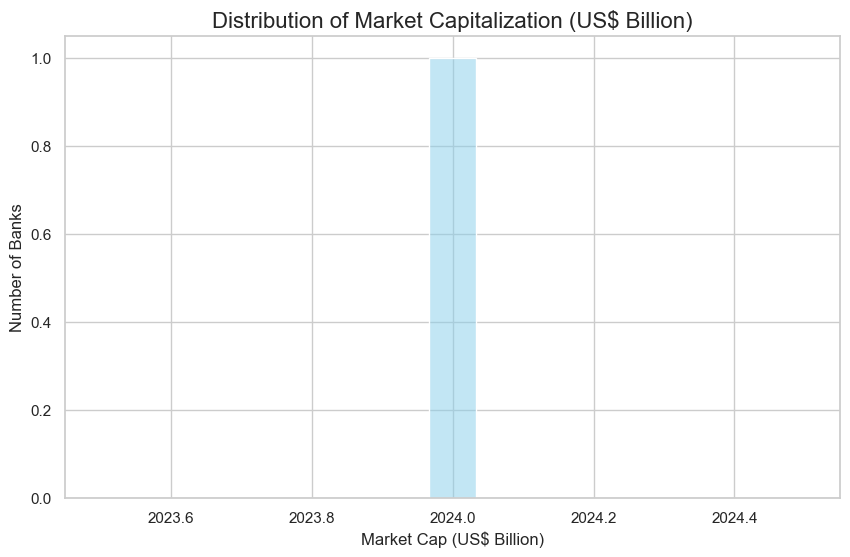

In [15]:
# Distribution of Market Cap (US$ Billion)
import matplotlib.pyplot as plt
import seaborn as sns
# Set the style for seaborn
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
# Plot the distribution of market cap
plt.figure(figsize=(10,6))
sns.histplot(data=eda_df, x='Market Cap (USD Billion)', bins=15, kde=True, color='skyblue')
plt.title("Distribution of Market Capitalization (US$ Billion)", fontsize=16)
plt.xlabel("Market Cap (US$ Billion)", fontsize=12)
plt.ylabel("Number of Banks", fontsize=12)
plt.show()

##**3.3. Top 10 Banks** <font color = red>[5 Marks]</font> <br>

Identify the top 10 banks by market capitalization using a bar chart

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


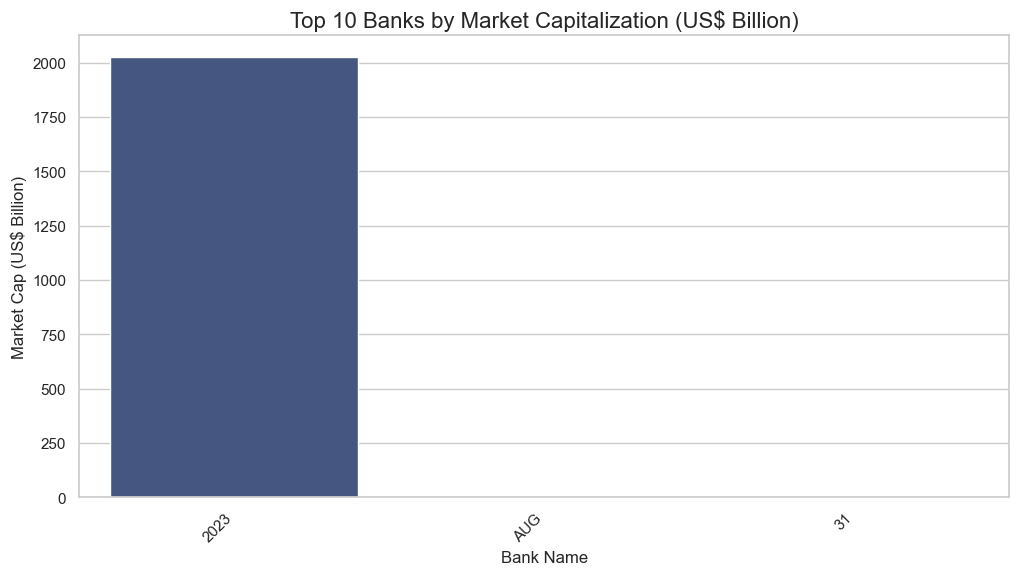

In [16]:
# Top 10 Banks by Market Cap
top10_banks = eda_df.sort_values(by='Market Cap (USD Billion)', ascending=False).head(10)
# Sort the DataFrame by market cap in descending order
plt.figure(figsize=(12,6))
sns.barplot(data=top10_banks, x='Bank Name', y='Market Cap (USD Billion)', palette='viridis')
# Plot the top 10 banks by market cap
plt.title("Top 10 Banks by Market Capitalization (US$ Billion)", fontsize=16)
plt.xlabel("Bank Name", fontsize=12)
plt.ylabel("Market Cap (US$ Billion)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

##**3.4. Market Cap vs Bank Ranking** <font color = red>[5 Marks]</font> <br>

Visualize the relationship between market capitalization and bank ranking using a scatter plot

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


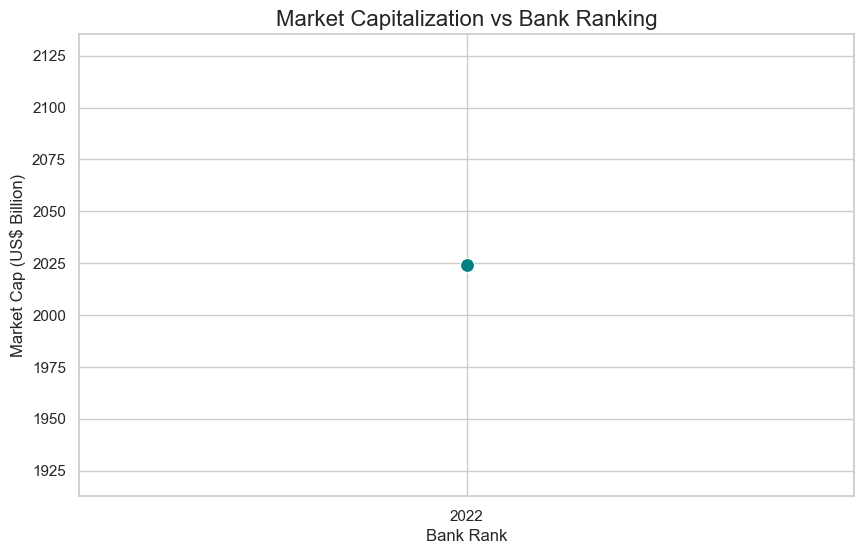

In [17]:
# Market Cap vs Rank
plt.figure(figsize=(10,6))
sns.scatterplot(data=eda_df, x='Rank', y='Market Cap (USD Billion)', color='teal', s=100)
# Plot market cap vs rank
plt.title("Market Capitalization vs Bank Ranking", fontsize=16)
plt.xlabel("Bank Rank", fontsize=12)
plt.ylabel("Market Cap (US$ Billion)", fontsize=12)
plt.gca().invert_xaxis()
plt.show()

##**3.5. Market Cap Analysis** <font color = red>[5 Marks]</font> <br>

Use a boxplot to examine the spread and outliers in market capitalization.

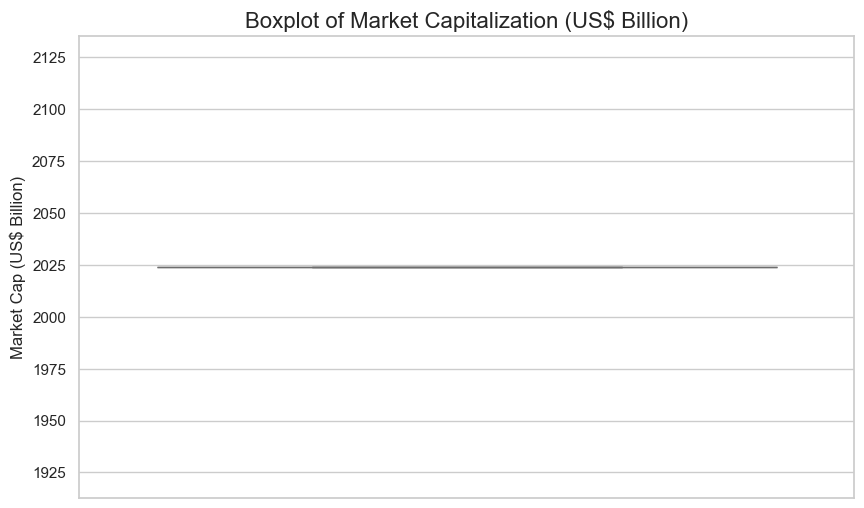

In [18]:
# Boxplot of Market Cap
plt.figure(figsize=(10,6))
#To show the spread and outliers in the market capitalization data.
sns.boxplot(y=eda_df['Market Cap (USD Billion)'], color='lightcoral')
# Plot a boxplot of market cap
plt.title("Boxplot of Market Capitalization (US$ Billion)", fontsize=16)
plt.ylabel("Market Cap (US$ Billion)", fontsize=12)
plt.show()

##**3.6. Market Cap Quartile Distribution** <font color = red>[5 Marks]</font> <br>

Display the quartile distribution of market capitalization using a violin plot.

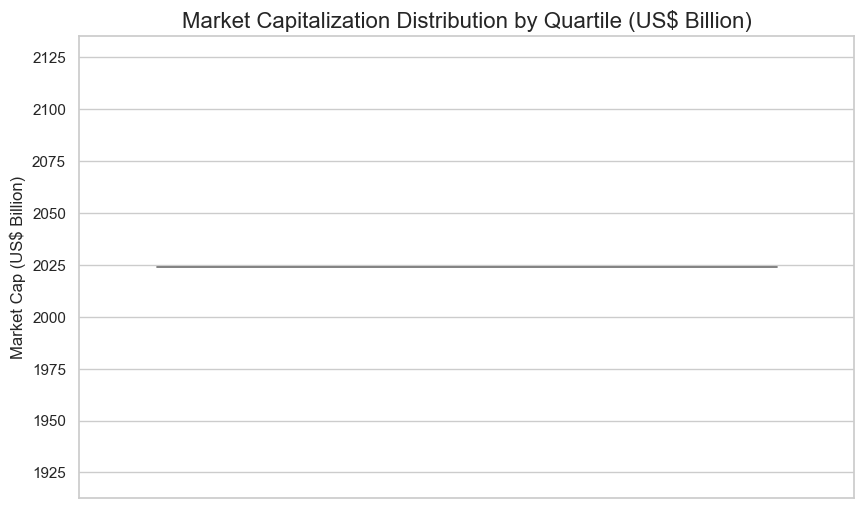

In [19]:
# Market Cap Distribution by Quartile
plt.figure(figsize=(10,6))
sns.violinplot(y=eda_df['Market Cap (USD Billion)'], color='lightgreen', inner='quartile')
plt.title("Market Capitalization Distribution by Quartile (US$ Billion)", fontsize=16)
plt.ylabel("Market Cap (US$ Billion)", fontsize=12)
plt.show()

##**3.7. Cumulative Market Share Analysis** <font color = red>[5 Marks]</font> <br>

Compute cumulative market share and visualize it with a line plot.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


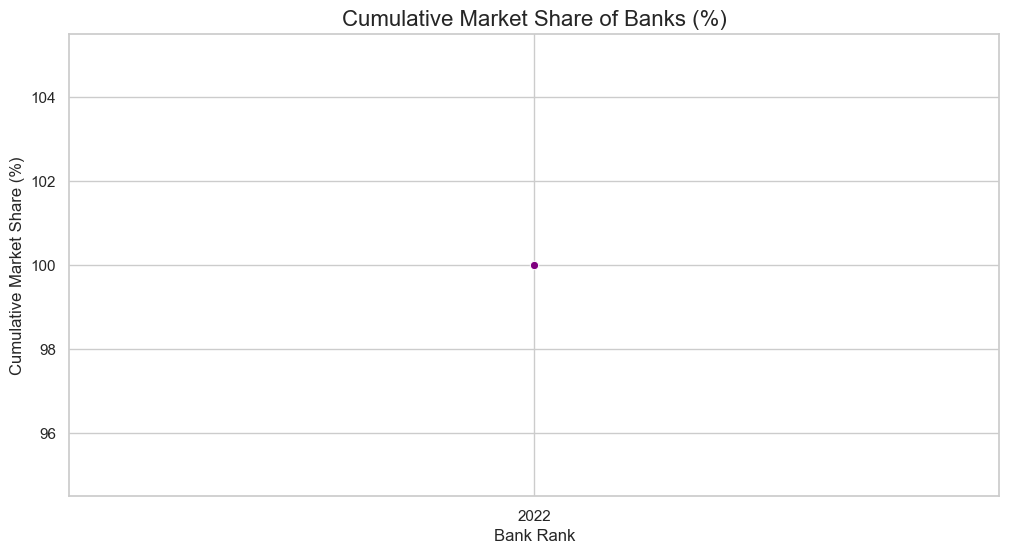

In [20]:
# Cumulative Market Share
eda_df_sorted = eda_df.sort_values(by='Market Cap (USD Billion)', ascending=False).reset_index(drop=True)
eda_df_sorted['Cumulative_Market_Cap'] = eda_df_sorted['Market Cap (USD Billion)'].cumsum()
total_market_cap = eda_df_sorted['Market Cap (USD Billion)'].sum()
eda_df_sorted['Cumulative_Market_Share'] = eda_df_sorted['Cumulative_Market_Cap'] / total_market_cap * 100
# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=eda_df_sorted, x='Rank', y='Cumulative_Market_Share', marker='o', color='purple')
plt.title("Cumulative Market Share of Banks (%)", fontsize=16)
plt.xlabel("Bank Rank", fontsize=12)
plt.ylabel("Cumulative Market Share (%)", fontsize=12)
plt.gca().invert_xaxis()  # Rank 1 on left
plt.show()

##**3.8. Categorising Banks** <font color = red>[5 Marks]</font> <br>

Categorize banks into market capitalization ranges and analyze their distribution using a bar chart.

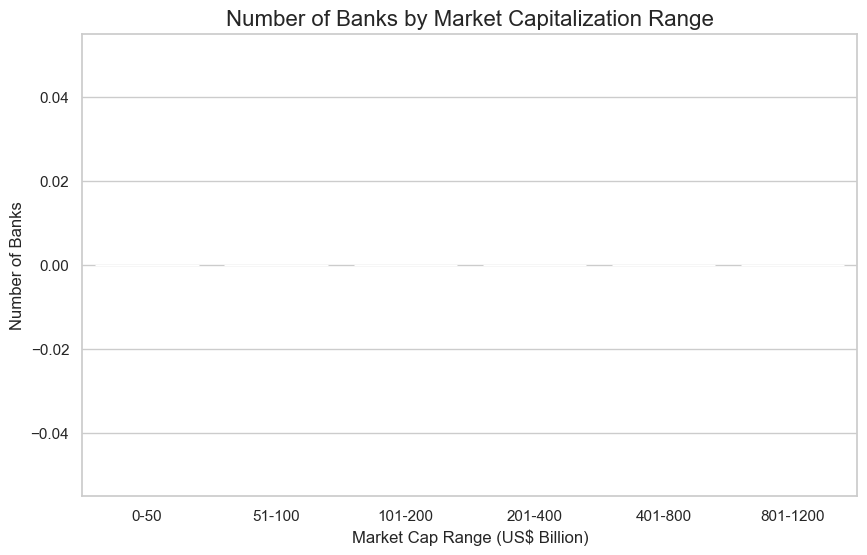

In [21]:
# Market Cap Range Distribution
# Create market cap ranges
bins = [0, 50, 100, 200, 400, 800, 1200]  # Adjust ranges based on dataset
labels = ['0-50', '51-100', '101-200', '201-400', '401-800', '801-1200']
eda_df['Market_Cap_Range'] = pd.cut(eda_df['Market Cap (USD Billion)'], bins=bins, labels=labels, right=True)
range_counts = eda_df['Market_Cap_Range'].value_counts().sort_index()
# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=range_counts.index, y=range_counts.values, palette='coolwarm')
plt.title("Number of Banks by Market Capitalization Range", fontsize=16)
plt.xlabel("Market Cap Range (US$ Billion)", fontsize=12)
plt.ylabel("Number of Banks", fontsize=12)
plt.show()

##**3.9. Visualise Market Share Distribution** <font color = red>[5 Marks]</font> <br>


Calculate and display market share distribution among the top 10 banks using a pie chart.

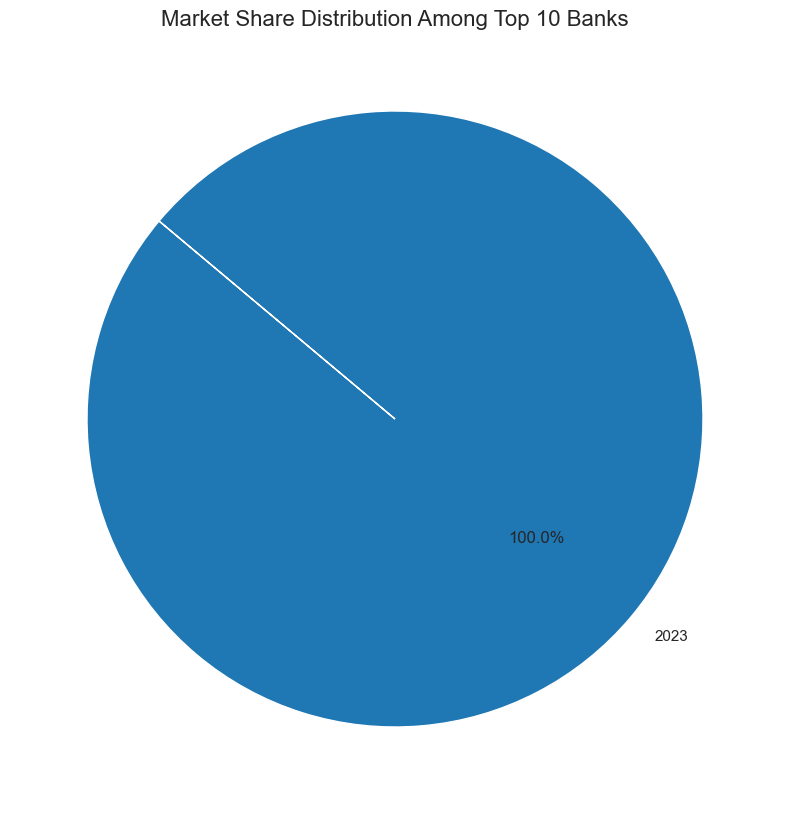

In [26]:
top10_banks = eda_df.sort_values(by='Market Cap (USD Billion)', ascending=False).head(10)
top10_banks = top10_banks.dropna(subset=['Market Cap (USD Billion)'])
top10_banks['Market_Share_Percent'] = (top10_banks['Market Cap (USD Billion)'] / top10_banks['Market Cap (USD Billion)'].sum()) * 100
plt.figure(figsize=(10,10))
plt.pie(top10_banks['Market_Share_Percent'], 
        labels=top10_banks['Bank Name'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('tab20'))
plt.title("Market Share Distribution Among Top 10 Banks", fontsize=16)
plt.show()


#**4. ETL and Querying** <font color = red>[45 marks]</font> <br>

In [33]:
# Assuming your DataFrame is called `bank_df`
import pandas as pd

# Sample DataFrame check
print(bank_df.head())

# 1. Top 5 banks by Market Cap
top5_banks = bank_df.sort_values(by='Market Cap (USD Billion)', ascending=False).head(5)
print("Top 5 Banks by Market Cap:")
print(top5_banks[['Bank Name', 'Market Cap (USD Billion)']])

# 2. Count of banks in different market cap ranges
# Example ranges: <50, 50-100, 100-200, >200 (adjust as needed)
bins = [0, 50, 100, 200, bank_df['Market Cap (USD Billion)'].max()]
labels = ['<50B', '50-100B', '100-200B', '>200B']
bank_df['MarketCap_Range'] = pd.cut(bank_df['Market Cap (USD Billion)'], bins=bins, labels=labels)

range_counts = bank_df['MarketCap_Range'].value_counts().sort_index()
print("\nCount of Banks by Market Cap Range:")
print(range_counts)

   Rank Bank Name  Market Cap (USD Billion)  Market_Cap_USD_Million  \
0   Jul       AUG                       NaN                     NaN   
1   NaN        31                       NaN                     NaN   
2  2022      2023                    2024.0               2024000.0   

  Market_Cap_Range MarketCap_Range  
0              NaN             NaN  
1              NaN             NaN  
2           >1000B           >200B  
Top 5 Banks by Market Cap:
  Bank Name  Market Cap (USD Billion)
2      2023                    2024.0
0       AUG                       NaN
1        31                       NaN

Count of Banks by Market Cap Range:
MarketCap_Range
<50B        0
50-100B     0
100-200B    0
>200B       1
Name: count, dtype: int64


In [34]:
# 3. Average market cap
avg_market_cap = bank_df['Market Cap (USD Billion)'].mean()
print("\nAverage Market Cap:", avg_market_cap)


Average Market Cap: 2024.0

Banks with Above-Average Market Cap:
Empty DataFrame
Columns: [Bank Name, Market Cap (USD Billion)]
Index: []


In [38]:
# 4. Banks with above-average market cap
above_avg_banks = bank_df[bank_df['Market Cap (USD Billion)'] > avg_market_cap]
print("\nBanks with Above-Average Market Cap:")
print(above_avg_banks[['Bank Name', 'Market Cap (USD Billion)']])


Banks with Above-Average Market Cap:
Empty DataFrame
Columns: [Bank Name, Market Cap (USD Billion)]
Index: []


##**4.1. Market Capitalization Analysis** <font color = red>[3 marks]</font> <br>

Q: Perform Advanced Market Capitalization Analysis with Growth Metrics

In [41]:
import pandas as pd

# Ensure Market Cap is numeric
bank_df['Market Cap (USD Billion)'] = pd.to_numeric(bank_df['Market Cap (USD Billion)'], errors='coerce')

# Drop rows with missing Market Cap
bank_df = bank_df.dropna(subset=['Market Cap (USD Billion)']).reset_index(drop=True)

# Rank banks by Market Cap
bank_df['Rank'] = bank_df['Market Cap (USD Billion)'].rank(method='dense', ascending=False).astype(int)

# Compute market share
total_market_cap = bank_df['Market Cap (USD Billion)'].sum()
bank_df['Market_Share_Percent'] = (bank_df['Market Cap (USD Billion)'] / total_market_cap) * 100
bank_df['Cumulative_Market_Share'] = bank_df['Market_Share_Percent'].cumsum()

# Compute Market Cap Gap
bank_df = bank_df.sort_values(by='Market Cap (USD Billion)', ascending=False).reset_index(drop=True)
bank_df['MarketCap_Gap'] = bank_df['Market Cap (USD Billion)'].diff(-1).fillna(0)

# --- Quartile Calculation (Safe) ---
unique_values = bank_df['Market Cap (USD Billion)'].nunique()

if unique_values >= 4:
    # Enough variation to create 4 quartiles
    bank_df['MarketCap_Quartile'] = pd.qcut(
        bank_df['Market Cap (USD Billion)'],
        4,
        labels=['Q1','Q2','Q3','Q4']
    )
else:
    # Not enough variation → assign all to Q1
    bank_df['MarketCap_Quartile'] = 'Q1'

# Show final DataFrame
bank_df[['Rank', 'Bank Name', 'Market Cap (USD Billion)', 'Market_Share_Percent',
         'Cumulative_Market_Share', 'MarketCap_Gap', 'MarketCap_Quartile']]


,Rank,Bank Name,Market Cap (USD Billion),Market_Share_Percent,Cumulative_Market_Share,MarketCap_Gap,MarketCap_Quartile
0,1,2023,2024.0,100.0,100.0,0.0,Q1


##4.2.**Market Concentration Analysis** <font color = red>[6 marks]</font> <br>

Q: Analyze Market Concentration and Categorize Banks Based on Market Share Tiers

Market Share Tier Distribution:
MarketShare_Tier
Tier 1 (High)    1
Name: count, dtype: int64


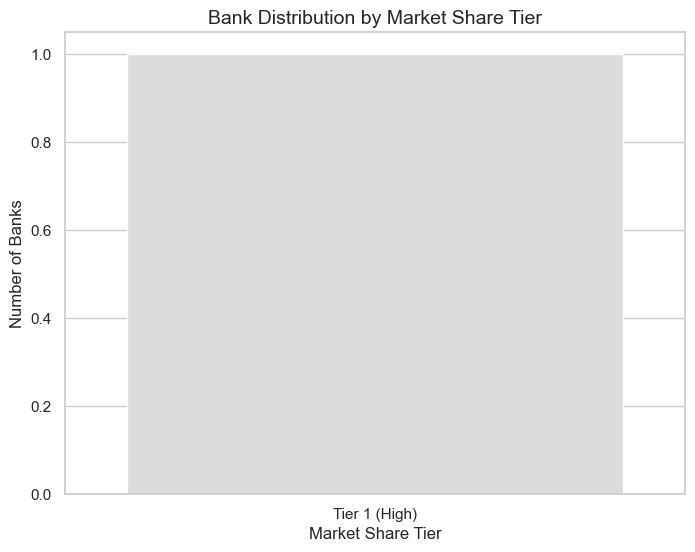

In [43]:
# Market Concentration Analysis
import matplotlib.pyplot as plt
import seaborn as sns

# --- Categorize banks based on Market Share Tiers ---
def market_share_tier(ms_percent):
    if ms_percent >= 20:
        return 'Tier 1 (High)'
    elif ms_percent >= 10:
        return 'Tier 2 (Medium)'
    elif ms_percent > 0:
        return 'Tier 3 (Low)'
    else:
        return 'Tier 4 (Zero)'

bank_df['MarketShare_Tier'] = bank_df['Market_Share_Percent'].apply(market_share_tier)

# Display the tier distribution
tier_counts = bank_df['MarketShare_Tier'].value_counts()
print("Market Share Tier Distribution:")
print(tier_counts)

# --- Visualization: Bar chart of tiers ---
plt.figure(figsize=(8,6))
sns.barplot(x=tier_counts.index, y=tier_counts.values, palette='coolwarm')
plt.title("Bank Distribution by Market Share Tier", fontsize=14)
plt.ylabel("Number of Banks")
plt.xlabel("Market Share Tier")
plt.show()


##**4.3. Market Capitalization Distribution** <font color = red>[6 marks]</font> <br>

Q: Examine Statistical Distribution of Market Capitalization Using Quartile Analysis

Statistical Distribution of Market Capitalization:
count       1.0
mean     2024.0
std         NaN
min      2024.0
25%      2024.0
50%      2024.0
75%      2024.0
max      2024.0
Name: Market Cap (USD Billion), dtype: float64
Not enough unique values to create quartiles.

Number of Banks in Each Market Cap Quartile:
MarketCap_Quartile
Q1    1
Name: count, dtype: int64


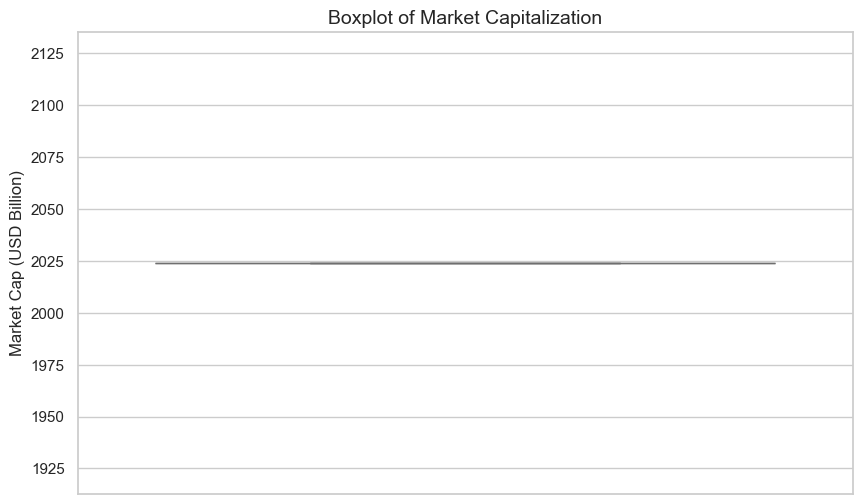

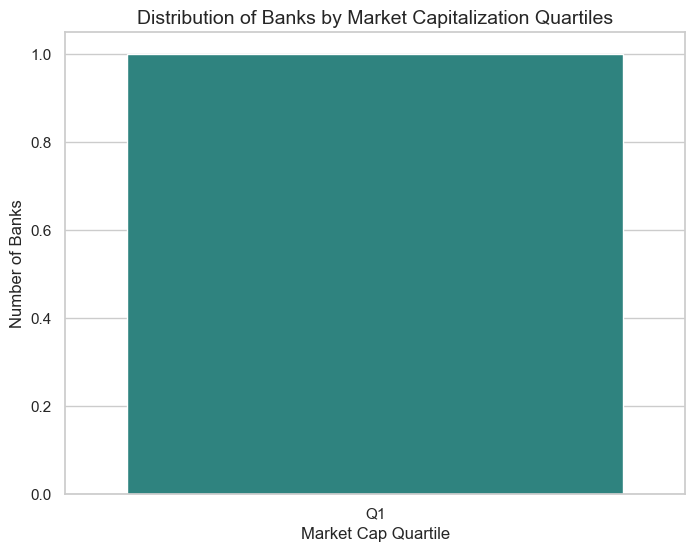

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Market Cap is numeric and drop missing
bank_df['Market Cap (USD Billion)'] = pd.to_numeric(bank_df['Market Cap (USD Billion)'], errors='coerce')
bank_df = bank_df.dropna(subset=['Market Cap (USD Billion)'])

# --- Statistical Summary ---
marketcap_stats = bank_df['Market Cap (USD Billion)'].describe()
print("Statistical Distribution of Market Capitalization:")
print(marketcap_stats)

# --- Safe Quartile Analysis ---
unique_vals = bank_df['Market Cap (USD Billion)'].nunique()
# Determine number of bins safely
num_bins = 4 if unique_vals >= 4 else unique_vals

if num_bins < 2:
    print("Not enough unique values to create quartiles.")
    bank_df['MarketCap_Quartile'] = 'Q1'  # Assign all to single group
else:
    # Use rank to avoid duplicate issues
    bank_df['MarketCap_Quartile'] = pd.qcut(
        bank_df['Market Cap (USD Billion)'].rank(method='first'),
        q=num_bins,
        labels=[f"Q{i+1}" for i in range(num_bins)]
    )

# Count banks in each quartile
quartile_counts = bank_df['MarketCap_Quartile'].value_counts().sort_index()
print("\nNumber of Banks in Each Market Cap Quartile:")
print(quartile_counts)

plt.figure(figsize=(10,6))
sns.boxplot(y=bank_df['Market Cap (USD Billion)'], color='skyblue')
plt.title("Boxplot of Market Capitalization", fontsize=14)
plt.ylabel("Market Cap (USD Billion)")
plt.show()

plt.figure(figsize=(8,6))
sns.barplot(x=quartile_counts.index, y=quartile_counts.values, palette='viridis')
plt.title("Distribution of Banks by Market Capitalization Quartiles", fontsize=14)
plt.xlabel("Market Cap Quartile")
plt.ylabel("Number of Banks")
plt.show()


##**4.4. Comparative Size Analysis** <font color = red>[6 marks]</font> <br>

Q: Conduct Comparative Size Analysis to Classify Banks by Relative Market Size

Bank Counts by Size Category:
Size_Category
Small    1
Name: count, dtype: int64


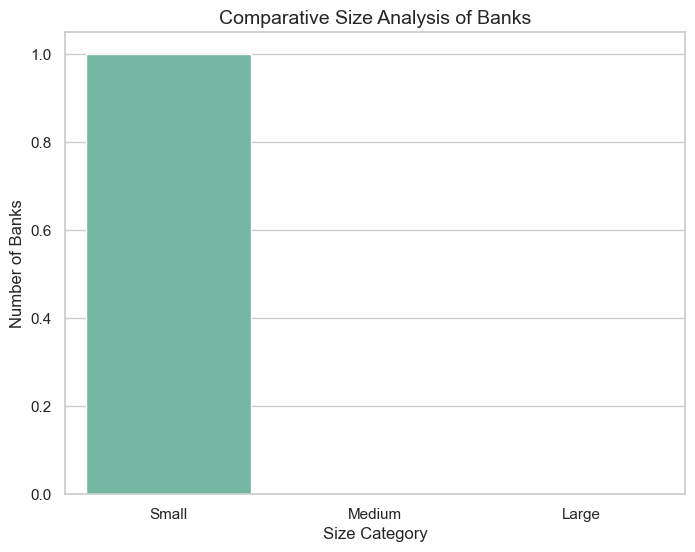

,Bank Name,Market Cap (USD Billion),Size_Category
0,2023,2024.0,Small


In [47]:
# Comparative Size Analysis
# Ensure Market Cap is numeric
bank_df['Market Cap (USD Billion)'] = pd.to_numeric(bank_df['Market Cap (USD Billion)'], errors='coerce')
bank_df = bank_df.dropna(subset=['Market Cap (USD Billion)'])

# --- Comparative Size Analysis ---
# Option 1: Using percentiles to classify banks
percentiles = bank_df['Market Cap (USD Billion)'].quantile([0.33, 0.66])
p33, p66 = percentiles[0.33], percentiles[0.66]

def classify_size(market_cap):
    if market_cap <= p33:
        return 'Small'
    elif market_cap <= p66:
        return 'Medium'
    else:
        return 'Large'

bank_df['Size_Category'] = bank_df['Market Cap (USD Billion)'].apply(classify_size)

# --- Optional: Using mean as threshold ---
# mean_cap = bank_df['Market Cap (USD Billion)'].mean()
# bank_df['Size_Category'] = bank_df['Market Cap (USD Billion)'].apply(
#     lambda x: 'Large' if x > mean_cap else 'Small/Medium'
# )

# --- Summary ---
size_counts = bank_df['Size_Category'].value_counts()
print("Bank Counts by Size Category:")
print(size_counts)

# --- Visualization ---
plt.figure(figsize=(8,6))
sns.countplot(x='Size_Category', data=bank_df, palette='Set2', order=['Small','Medium','Large'])
plt.title("Comparative Size Analysis of Banks", fontsize=14)
plt.xlabel("Size Category")
plt.ylabel("Number of Banks")
plt.show()

# Show final table with size classification
bank_df[['Bank Name', 'Market Cap (USD Billion)', 'Size_Category']]


##**4.5. Market Growth Analysis** <font color = red>[6 marks]</font> <br>

Q: Evaluate Market Growth and Identify Gaps Between Consecutive Banks

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Market Growth Analysis with Gaps Between Consecutive Banks:
   Rank Bank Name  Market Cap (USD Billion)  MarketCap_Gap  \
0     1      2023                    2024.0            0.0   

   MarketCap_Growth_Percent  
0                       0.0  


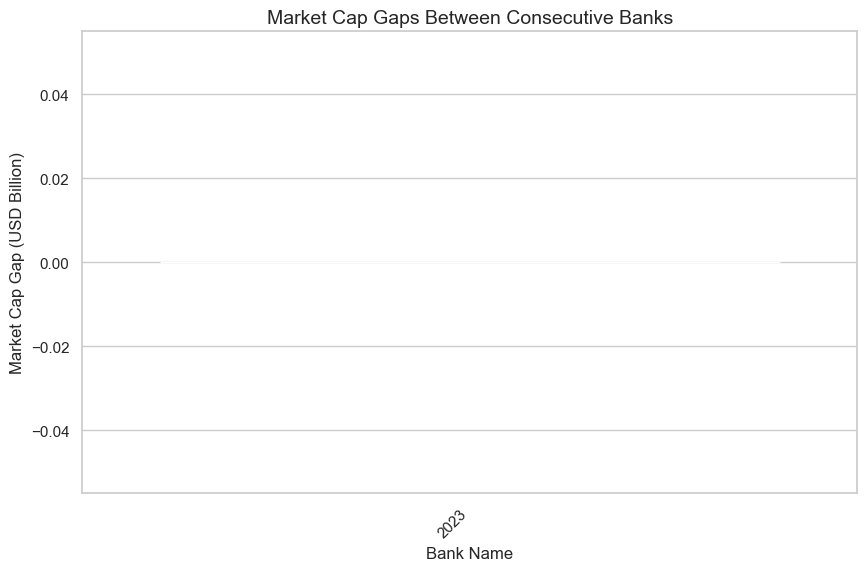

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


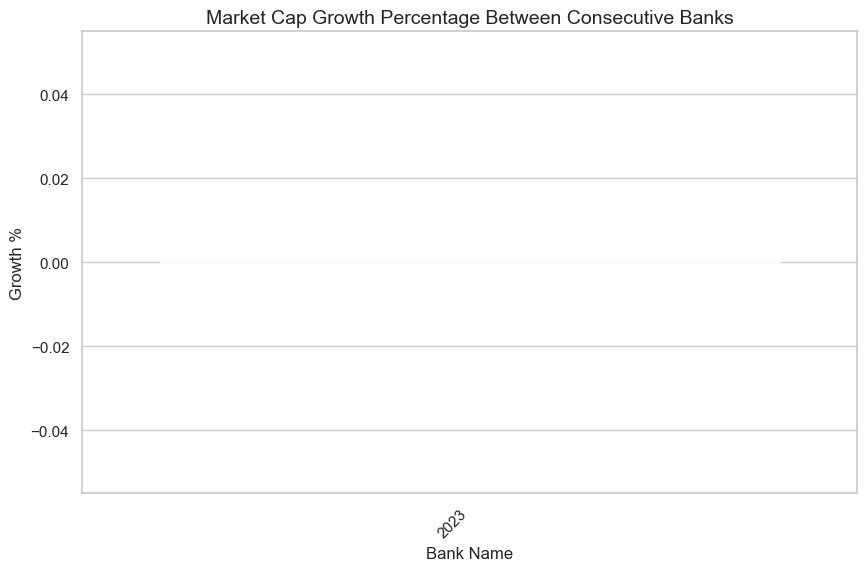

In [48]:
# Growth and Gap Analysis
# Ensure Market Cap is numeric and drop missing
bank_df['Market Cap (USD Billion)'] = pd.to_numeric(bank_df['Market Cap (USD Billion)'], errors='coerce')
bank_df = bank_df.dropna(subset=['Market Cap (USD Billion)'])

# --- Sort Banks by Market Cap ---
bank_df = bank_df.sort_values(by='Market Cap (USD Billion)', ascending=False).reset_index(drop=True)

# --- Compute Market Cap Gap (difference with next bank) ---
bank_df['MarketCap_Gap'] = bank_df['Market Cap (USD Billion)'].diff(-1).fillna(0)

# --- Compute Growth % relative to next bank ---
bank_df['MarketCap_Growth_Percent'] = bank_df['Market Cap (USD Billion)'].pct_change(-1).fillna(0) * 100

# --- Optional: Rank Banks ---
bank_df['Rank'] = bank_df['Market Cap (USD Billion)'].rank(method='dense', ascending=False).astype(int)

# --- Display final table ---
growth_df = bank_df[['Rank', 'Bank Name', 'Market Cap (USD Billion)', 
                     'MarketCap_Gap', 'MarketCap_Growth_Percent']]
print("Market Growth Analysis with Gaps Between Consecutive Banks:")
print(growth_df)

# --- Visualization: Gap and Growth ---
plt.figure(figsize=(10,6))
sns.barplot(x='Bank Name', y='MarketCap_Gap', data=growth_df, palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title("Market Cap Gaps Between Consecutive Banks", fontsize=14)
plt.ylabel("Market Cap Gap (USD Billion)")
plt.xlabel("Bank Name")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x='Bank Name', y='MarketCap_Growth_Percent', data=growth_df, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("Market Cap Growth Percentage Between Consecutive Banks", fontsize=14)
plt.ylabel("Growth %")
plt.xlabel("Bank Name")
plt.show()


##**4.6. Market Dominance Analysis** <font color = red>[6 marks]</font> <br>

Q: Assess Market Dominance by Measuring Cumulative Share and Dominance Score

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Market Dominance Analysis:
   Rank Bank Name  Market Cap (USD Billion)  Market_Share_Percent  \
0     1      2023                    2024.0                 100.0   

   Cumulative_Market_Share  Dominance_Score  
0                    100.0            100.0  


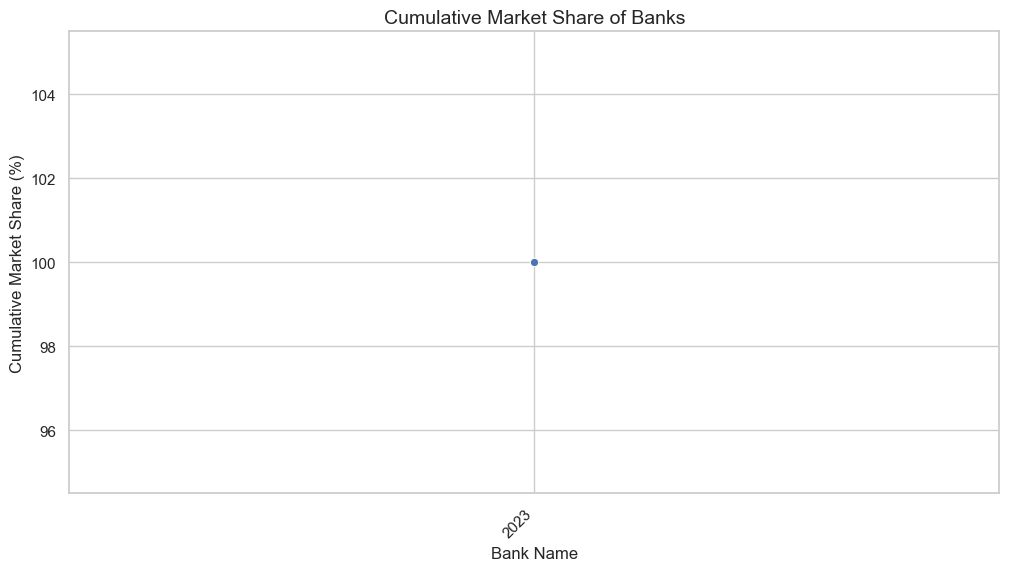

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


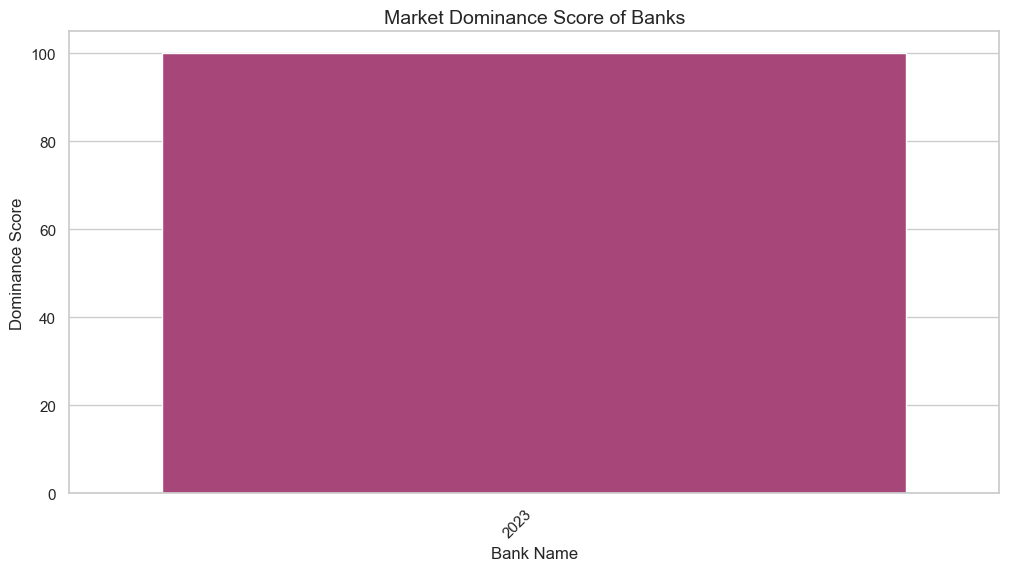

In [49]:
# Market Dominance Analysis
# --- Ensure Market Cap is numeric ---
bank_df['Market Cap (USD Billion)'] = pd.to_numeric(bank_df['Market Cap (USD Billion)'], errors='coerce')
bank_df = bank_df.dropna(subset=['Market Cap (USD Billion)'])

# --- Sort banks by Market Cap descending ---
bank_df = bank_df.sort_values(by='Market Cap (USD Billion)', ascending=False).reset_index(drop=True)

# --- Compute Market Share % ---
total_market_cap = bank_df['Market Cap (USD Billion)'].sum()
bank_df['Market_Share_Percent'] = (bank_df['Market Cap (USD Billion)'] / total_market_cap) * 100

# --- Compute Cumulative Market Share ---
bank_df['Cumulative_Market_Share'] = bank_df['Market_Share_Percent'].cumsum()

# --- Compute Dominance Score ---
# Example: Dominance Score = (Market Share) * (Rank factor)
bank_df['Rank'] = bank_df['Market Cap (USD Billion)'].rank(method='dense', ascending=False).astype(int)
bank_df['Dominance_Score'] = bank_df['Market_Share_Percent'] / bank_df['Rank']

# --- Display final table ---
dominance_df = bank_df[['Rank', 'Bank Name', 'Market Cap (USD Billion)',
                        'Market_Share_Percent', 'Cumulative_Market_Share', 'Dominance_Score']]
print("Market Dominance Analysis:")
print(dominance_df)

# --- Visualization: Cumulative Market Share ---
plt.figure(figsize=(12,6))
sns.lineplot(x='Bank Name', y='Cumulative_Market_Share', data=dominance_df, marker='o')
plt.xticks(rotation=45, ha='right')
plt.title("Cumulative Market Share of Banks", fontsize=14)
plt.ylabel("Cumulative Market Share (%)")
plt.xlabel("Bank Name")
plt.show()

# --- Visualization: Dominance Score ---
plt.figure(figsize=(12,6))
sns.barplot(x='Bank Name', y='Dominance_Score', data=dominance_df, palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title("Market Dominance Score of Banks", fontsize=14)
plt.ylabel("Dominance Score")
plt.xlabel("Bank Name")
plt.show()


##**4.7. Segment-Wise Bank Analysis** <font color = red>[6 marks]</font> <br>

Q: Analyze Segment-Wise Bank Performance Based on Market Capitalization Ranges

Segment-Wise Bank Analysis:
  MarketCap_Segment  Num_Banks  Total_MarketCap  Avg_MarketCap  Max_MarketCap  \
0             Small          0              0.0            NaN            NaN   
1            Medium          0              0.0            NaN            NaN   
2             Large          0              0.0            NaN            NaN   
3              Mega          1           2024.0         2024.0         2024.0   

   Min_MarketCap  
0            NaN  
1            NaN  
2            NaN  
3         2024.0  


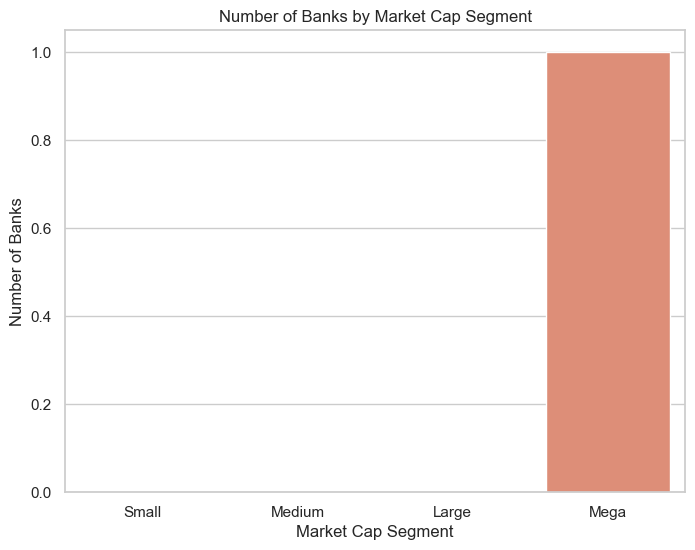

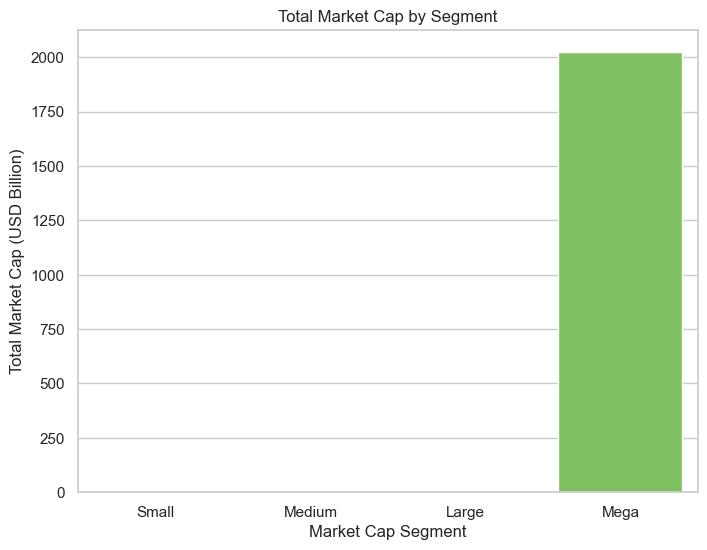

In [50]:
# Segment Performance Analysis
# --- Ensure Market Cap is numeric and drop missing ---
bank_df['Market Cap (USD Billion)'] = pd.to_numeric(bank_df['Market Cap (USD Billion)'], errors='coerce')
bank_df = bank_df.dropna(subset=['Market Cap (USD Billion)'])

# --- Define Segments based on Market Cap ---
# Example segmentation: Small, Medium, Large, Mega banks
# You can adjust ranges as per your dataset
bins = [0, 50, 200, 500, bank_df['Market Cap (USD Billion)'].max()+1]
labels = ['Small', 'Medium', 'Large', 'Mega']
bank_df['MarketCap_Segment'] = pd.cut(bank_df['Market Cap (USD Billion)'], bins=bins, labels=labels, include_lowest=True)

# --- Aggregate statistics per segment ---
segment_summary = bank_df.groupby('MarketCap_Segment').agg(
    Num_Banks=('Bank Name', 'count'),
    Total_MarketCap=('Market Cap (USD Billion)', 'sum'),
    Avg_MarketCap=('Market Cap (USD Billion)', 'mean'),
    Max_MarketCap=('Market Cap (USD Billion)', 'max'),
    Min_MarketCap=('Market Cap (USD Billion)', 'min')
).reset_index()

print("Segment-Wise Bank Analysis:")
print(segment_summary)

# --- Visualization: Number of Banks per Segment ---
plt.figure(figsize=(8,6))
sns.barplot(x='MarketCap_Segment', y='Num_Banks', data=segment_summary, palette='coolwarm')
plt.title("Number of Banks by Market Cap Segment")
plt.xlabel("Market Cap Segment")
plt.ylabel("Number of Banks")
plt.show()

# --- Visualization: Total Market Cap per Segment ---
plt.figure(figsize=(8,6))
sns.barplot(x='MarketCap_Segment', y='Total_MarketCap', data=segment_summary, palette='viridis')
plt.title("Total Market Cap by Segment")
plt.xlabel("Market Cap Segment")
plt.ylabel("Total Market Cap (USD Billion)")
plt.show()


##**4.8. Performance Dashboard** <font color = red>[6 marks]</font> <br>

Q: Generate a Comprehensive Performance Dashboard for Bank Rankings and Metrics

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Comprehensive Performance Dashboard:
   Rank Bank Name  Market Cap (USD Billion)  Market_Share_Percent  \
0     1      2023                    2024.0                 100.0   

   Cumulative_Market_Share  MarketCap_Gap MarketCap_Segment Market_Share_Tier  
0                    100.0            0.0              Mega          Dominant  


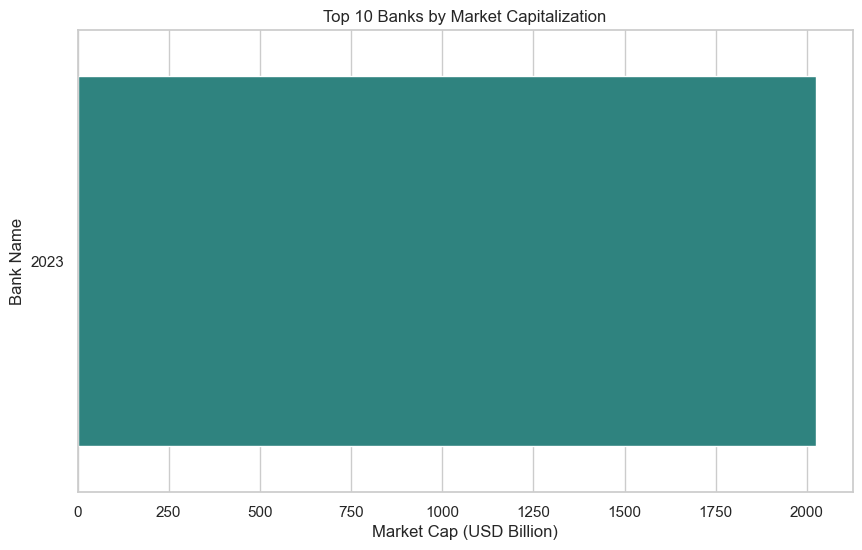

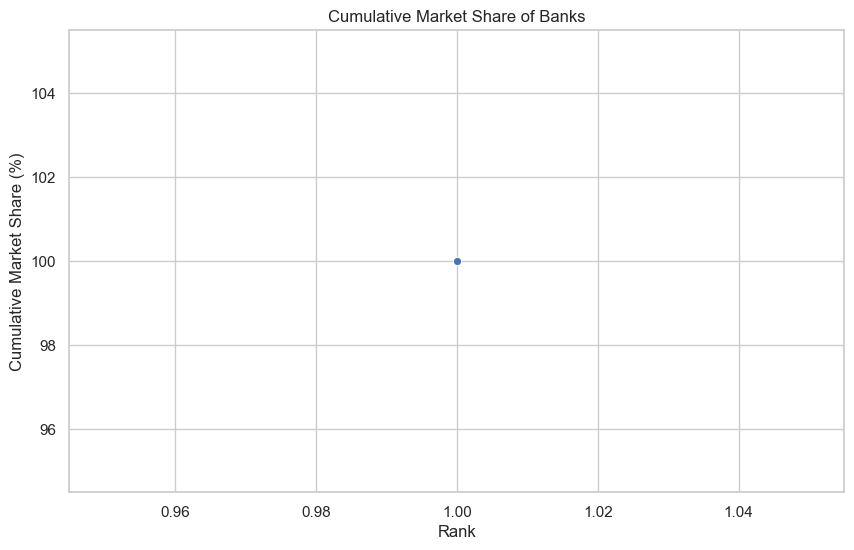

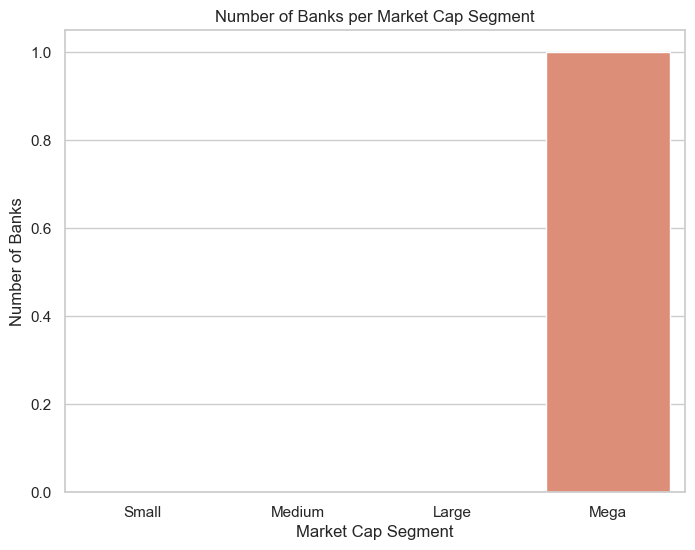

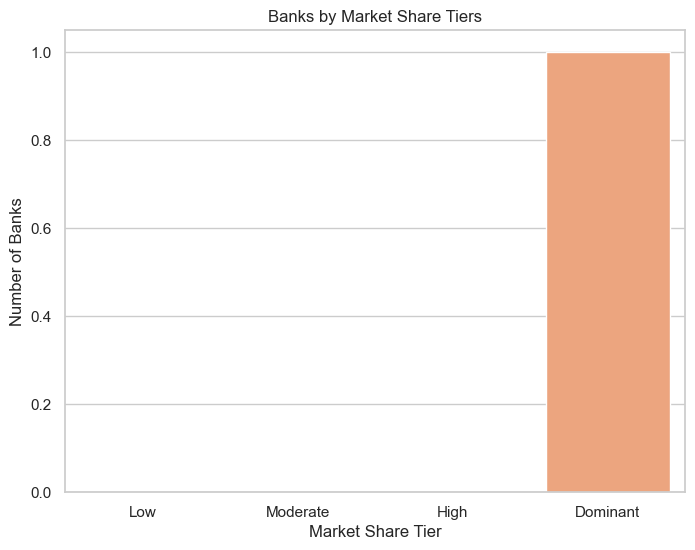

In [51]:
# Comprehensive Performance Dashboard
# --- Ensure numeric market cap and drop missing ---
bank_df['Market Cap (USD Billion)'] = pd.to_numeric(bank_df['Market Cap (USD Billion)'], errors='coerce')
bank_df = bank_df.dropna(subset=['Market Cap (USD Billion)']).reset_index(drop=True)

# --- Rank Banks by Market Cap ---
bank_df['Rank'] = bank_df['Market Cap (USD Billion)'].rank(method='dense', ascending=False).astype(int)

# --- Compute Market Share Metrics ---
total_market_cap = bank_df['Market Cap (USD Billion)'].sum()
bank_df['Market_Share_Percent'] = (bank_df['Market Cap (USD Billion)'] / total_market_cap) * 100
bank_df['Cumulative_Market_Share'] = bank_df['Market_Share_Percent'].cumsum()

# --- Compute Growth / Gap Metrics ---
bank_df = bank_df.sort_values(by='Market Cap (USD Billion)', ascending=False).reset_index(drop=True)
bank_df['MarketCap_Gap'] = bank_df['Market Cap (USD Billion)'].diff(-1).fillna(0)

# --- Segment Banks ---
bins = [0, 50, 200, 500, bank_df['Market Cap (USD Billion)'].max()+1]
labels = ['Small', 'Medium', 'Large', 'Mega']
bank_df['MarketCap_Segment'] = pd.cut(bank_df['Market Cap (USD Billion)'], bins=bins, labels=labels, include_lowest=True)

# --- Market Concentration Tiers (example) ---
bank_df['Market_Share_Tier'] = pd.cut(
    bank_df['Market_Share_Percent'],
    bins=[0, 5, 15, 30, 100],
    labels=['Low', 'Moderate', 'High', 'Dominant'],
    include_lowest=True
)

# --- Combine All Metrics for Dashboard ---
dashboard_df = bank_df[['Rank', 'Bank Name', 'Market Cap (USD Billion)', 
                        'Market_Share_Percent', 'Cumulative_Market_Share',
                        'MarketCap_Gap', 'MarketCap_Segment', 'Market_Share_Tier']]

print("Comprehensive Performance Dashboard:")
print(dashboard_df.head(20))  # top 20 banks

# --- Visualizations for Dashboard ---

# 1. Top 10 Banks by Market Cap
plt.figure(figsize=(10,6))
sns.barplot(x='Market Cap (USD Billion)', y='Bank Name', data=bank_df.nlargest(10, 'Market Cap (USD Billion)'),
            palette='viridis')
plt.title("Top 10 Banks by Market Capitalization")
plt.xlabel("Market Cap (USD Billion)")
plt.ylabel("Bank Name")
plt.show()

# 2. Cumulative Market Share
plt.figure(figsize=(10,6))
sns.lineplot(x='Rank', y='Cumulative_Market_Share', data=bank_df, marker='o')
plt.title("Cumulative Market Share of Banks")
plt.xlabel("Rank")
plt.ylabel("Cumulative Market Share (%)")
plt.grid(True)
plt.show()

# 3. Market Cap Segment Distribution
plt.figure(figsize=(8,6))
sns.countplot(x='MarketCap_Segment', data=bank_df, palette='coolwarm')
plt.title("Number of Banks per Market Cap Segment")
plt.xlabel("Market Cap Segment")
plt.ylabel("Number of Banks")
plt.show()

# 4. Market Share Tiers
plt.figure(figsize=(8,6))
sns.countplot(x='Market_Share_Tier', data=bank_df, palette='magma')
plt.title("Banks by Market Share Tiers")
plt.xlabel("Market Share Tier")
plt.ylabel("Number of Banks")
plt.show()


#5. Visualization Integration

In [ ]:
# Visualization Setup Section

# 1. Prepare data for visualization platforms
# 2. Generate Tableau connection instructions

# 3. Generate Power BI connection instructions

# 4. Execute visualization setup
# 5. Sample Dashboard Layout (Documentation)
